# Stellar Sample Characterization

This notebook characterizes the pool of nearby bright TESS stars we plan to use for the stellar world model.
It covers sample selection, physical parameter distributions, TESS data availability, and a demonstration that Gaia BP-RP color breaks the log g / Teff degeneracy.

**Put together a notebook to explore two suggestions — the bright nearby stars filter and the degeneracy issue**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astroquery.mast import Catalogs
import lightkurve as lk

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

---
## Section 1: Query Bright Nearby Stars from TIC v8 (TESS Input Catalog)

Criteria: TESS magnitude < 10, parallax > 10 mas (distance < 100 pc), object type = STAR.

In [2]:
import time

# MAST sometimes drops the connection on large payloads — bump the client timeout
Catalogs.TIMEOUT = 300

def query_tic_with_retry(criteria, max_retries=4, base_wait=8):
    """Query MAST TIC with retry on connection errors (RemoteDisconnected, etc)."""
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            print(f"  MAST attempt {attempt}/{max_retries} with {criteria}...")
            return Catalogs.query_criteria(catalog="TIC", **criteria)
        except Exception as e:
            last_err = e
            print(f"    {type(e).__name__}: {str(e)[:150]}")
            if attempt < max_retries:
                wait = base_wait * attempt
                print(f"    Retrying in {wait}s...")
                time.sleep(wait)
    raise last_err

print("Querying TIC v8 from MAST...")
try:
    catalog = query_tic_with_retry(dict(
        Tmag=[-99, 10],
        plx=[10, 9999],
        objType="STAR",
    ))
except Exception as e:
    print(f"\nQuery failed after retries ({type(e).__name__}).")
    print("Falling back to a tighter filter (plx > 20 mas, d < 50 pc) to shrink the payload...")
    catalog = query_tic_with_retry(dict(
        Tmag=[-99, 10],
        plx=[20, 9999],
        objType="STAR",
    ))

print(f"\nMAST returned {len(catalog)} rows.\n")

# Convert full table first — column names vary by astroquery version (e.g. gaiaBP vs gaiaBp)
df_all = catalog.to_pandas()
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Case-insensitive column lookup
col_lower = {c.lower(): c for c in df_all.columns}

def get_col(*candidates):
    for name in candidates:
        found = col_lower.get(name.lower())
        if found:
            return found
    return None

bp_col = get_col('gaiaBP', 'gaiaBp', 'gaia_bp')
rp_col = get_col('gaiaRP', 'gaiaRp', 'gaia_rp')
g_col  = get_col('GAIAmag', 'gaiamag', 'gaia_g')
print(f"Gaia columns found → G: {g_col},  BP: {bp_col},  RP: {rp_col}")

required_cols = ['ID', 'Tmag', 'Teff', 'logg', 'MH', 'plx', 'rad', 'mass']
extra_cols = [c for c in [g_col, bp_col, rp_col] if c is not None]
df_raw = df_all[required_cols + extra_cols].copy()

# Standardize names so downstream cells always see 'gaiaBp', 'gaiaRp', 'GAIAmag'
rename = {}
if bp_col and bp_col != 'gaiaBp':  rename[bp_col] = 'gaiaBp'
if rp_col and rp_col != 'gaiaRp':  rename[rp_col] = 'gaiaRp'
if g_col  and g_col  != 'GAIAmag': rename[g_col]  = 'GAIAmag'
if rename:
    df_raw = df_raw.rename(columns=rename)

print(f"Total stars returned: {len(df_raw)}")
df_raw.head(10)

Querying TIC v8 from MAST...
  MAST attempt 1/4 with {'Tmag': [-99, 10], 'plx': [10, 9999], 'objType': 'STAR'}...

MAST returned 41233 rows.

Gaia columns found → G: GAIAmag,  BP: gaiabp,  RP: gaiarp
Total stars returned: 41233


,ID,Tmag,Teff,logg,MH,plx,rad,mass,GAIAmag,gaiaBp,gaiaRp
0,117926681,8.3179,6017.00,4.31067,NaN,11.6855,1.220000,1.11,8.71114,9.02110,8.27469
1,117930174,9.7533,5182.27,4.62024,-0.181000,12.7535,0.760599,0.88,10.27940,10.72350,9.70542
2,117956546,5.0430,5365.25,NaN,-0.844312,79.0696,0.866258,NaN,5.52379,5.93117,5.00820
3,201439491,8.5870,5292.00,4.51655,NaN,18.2357,0.871523,0.91,9.09865,9.52609,8.53870
4,346738795,8.8501,5944.00,4.49130,NaN,11.5979,0.981968,1.09,9.25470,9.57601,8.80730
5,373061126,6.3452,7133.52,4.03529,NaN,14.2137,2.004870,1.59,6.46584,6.57503,6.32484
6,118032369,8.2663,NaN,NaN,NaN,12.0757,NaN,NaN,8.72364,8.90938,8.03473
7,201517645,9.8970,4848.00,4.38297,NaN,10.9697,0.947030,0.79,10.49620,11.02240,9.84439
8,238301314,6.9059,5908.52,3.93936,NaN,15.2903,1.836740,1.07,7.32642,7.66953,6.86918
9,257502302,6.7599,5743.00,NaN,NaN,23.1990,NaN,NaN,7.19543,7.46300,6.63251


In [8]:
df = df_raw.dropna(subset=['Teff', 'logg']).copy()
print(f"Stars after dropping rows with null Teff or log g: {len(df)}")
print(f"  (removed {len(df_raw) - len(df)} rows)")

Stars after dropping rows with null Teff or log g: 35078
  (removed 6155 rows)


### What this section does
Query the TESS Input Catalog v8 (TIC v8) on MAST for all bright, nearby stars: **Tmag < 10** (bright enough for high-precision photometry), **parallax > 10 mas** (distance < 100 pc, i.e. ~330 light-years), **object type = STAR**. Then drop any star missing a catalog Teff or log g, since those are the labels we need.

### Output interpretation
- **41,233 stars** pass the photometric and parallax cuts; **35,078 survive** after removing those with missing Teff or log g (6,155 removed due to catalog incompleteness — not every star has a spectroscopic measurement in TIC v8).
- No TESS light curves are involved yet — this section defines the *target pool* from catalog data alone.

### Discussion

> **How many stars survive? Should we tighten or loosen the cuts?**
>
> - Current cuts: Tmag < 10, plx > 10 mas, objType = STAR, non-null Teff & log g
> - Options to discuss: tighten to plx > 20 mas (< 50 pc) for higher completeness, or loosen Tmag < 12 to increase sample size

---
## Section 2: Physical Parameter Distributions

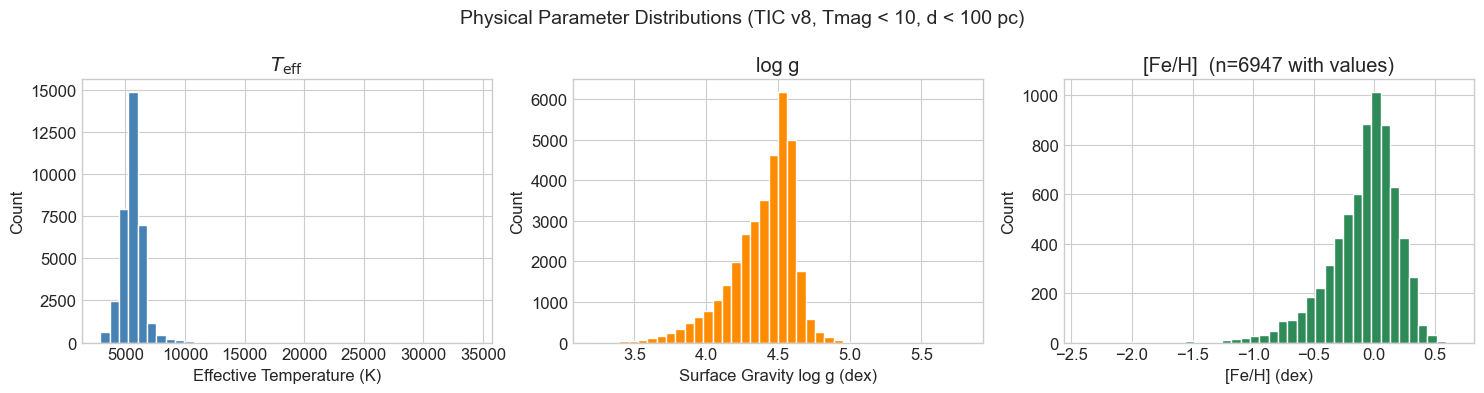

In [9]:
# 1x3 histograms: Teff, log g, [Fe/H]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Physical Parameter Distributions (TIC v8, Tmag < 10, d < 100 pc)', fontsize=14)

axes[0].hist(df['Teff'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Effective Temperature (K)')
axes[0].set_ylabel('Count')
axes[0].set_title('$T_{\\mathrm{eff}}$')

axes[1].hist(df['logg'].dropna(), bins=40, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Surface Gravity log g (dex)')
axes[1].set_ylabel('Count')
axes[1].set_title('log g')

feh = df['MH'].dropna()
axes[2].hist(feh, bins=40, color='seagreen', edgecolor='white')
axes[2].set_xlabel('[Fe/H] (dex)')
axes[2].set_ylabel('Count')
axes[2].set_title('[Fe/H]')
axes[2].set_title(f'[Fe/H]  (n={len(feh)} with values)')

plt.tight_layout()
plt.show()

**Question**: any regions on this HR diagram we should avoid? eg: stick to FGKM dwarfs 

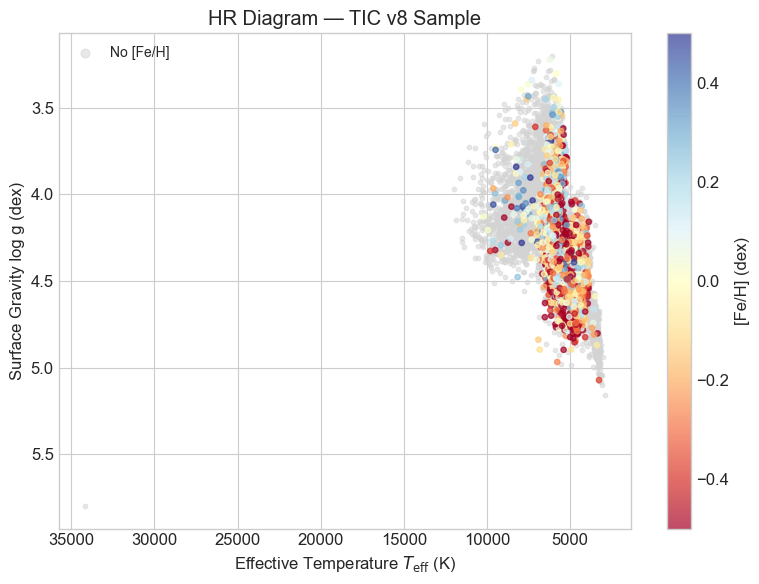

In [10]:
# HR diagram: Teff vs log g, colored by [Fe/H]
df_hr = df.dropna(subset=['MH'])
df_hr_nomh = df[df['MH'].isna()]

fig, ax = plt.subplots(figsize=(8, 6))

# Stars without [Fe/H] in grey
ax.scatter(df_hr_nomh['Teff'], df_hr_nomh['logg'], c='lightgrey', s=10, alpha=0.5, label='No [Fe/H]')

sc = ax.scatter(df_hr['Teff'], df_hr['logg'], c=df_hr['MH'],
                cmap='RdYlBu', s=15, alpha=0.7, vmin=-0.5, vmax=0.5)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('[Fe/H] (dex)')

ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('Effective Temperature $T_{\\mathrm{eff}}$ (K)')
ax.set_ylabel('Surface Gravity log g (dex)')
ax.set_title('HR Diagram — TIC v8 Sample')
ax.legend(markerscale=2, fontsize=10)

plt.tight_layout()
plt.show()

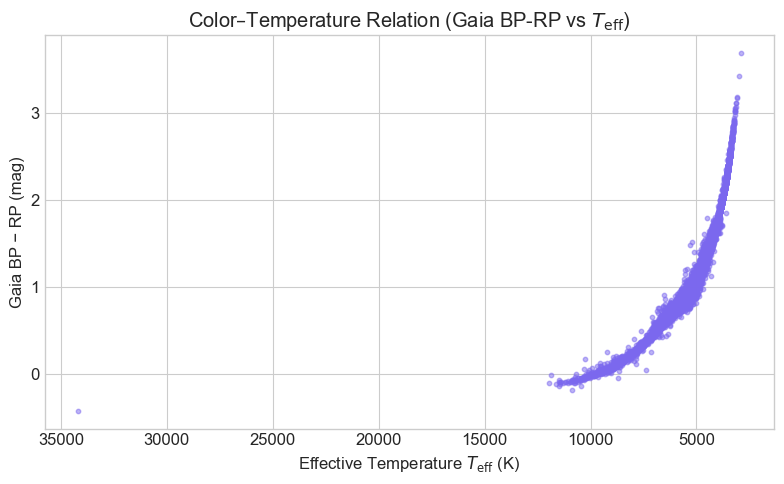

Stars with Gaia BP-RP color: 35078 / 35078 (100.0%)


In [11]:
# BP-RP color vs Teff — demonstrates what the second modality adds
df_color = df.dropna(subset=['gaiaBp', 'gaiaRp'])
df_color = df_color.copy()
df_color['BP_RP'] = df_color['gaiaBp'] - df_color['gaiaRp']

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_color['Teff'], df_color['BP_RP'], s=10, alpha=0.5, color='mediumslateblue')
ax.invert_xaxis()
ax.set_xlabel('Effective Temperature $T_{\\mathrm{eff}}$ (K)')
ax.set_ylabel('Gaia BP − RP (mag)')
ax.set_title('Color–Temperature Relation (Gaia BP-RP vs $T_{\\mathrm{eff}}$)')

plt.tight_layout()
plt.show()

print(f"Stars with Gaia BP-RP color: {len(df_color)} / {len(df)} ({100*len(df_color)/len(df):.1f}%)")

### What this section does
Plot the physical parameter distributions of the 35,078-star sample: effective temperature (Teff), surface gravity (log g), and metallicity ([Fe/H]). Then show an HR diagram and a Gaia color–temperature relation to understand stellar diversity and motivate using color as a second model input.

### Output interpretation
- **Teff**: Dominated by FGK-type stars (4000–7000 K), as expected for a volume-limited solar neighborhood sample. The sparse hot tail (> 10,000 K) includes A/B stars and some evolved objects — candidates for exclusion.
- **log g**: Peak near 4.4–4.6 dex, consistent with main-sequence dwarfs. The low-end tail (log g < 4.0) is subgiants and giants.
- **[Fe/H]**: Centered near solar metallicity (0.0 dex), slight metal-poor tail. Only ~20% of stars have a catalog [Fe/H] — the rest are unknown, which limits its use as a training label.
- **HR diagram**: Confirms a clean main sequence. The evolved branch at low log g is where we would apply a dwarf-only cut (log g > 3.5) if desired.
- **BP-RP vs Teff**: Near-monotonic, tight relation — Gaia color is a direct, low-noise temperature proxy. This is the strongest visual argument for using it as a second model input.

### Discussion

> **Should we restrict to a specific Teff range (e.g., 4000–7000 K for FGK stars)? Any evolutionary stages to exclude?**
>
> - The HR diagram shows both main-sequence and evolved (giant/subgiant) populations
> - Possible restriction: log g > 3.5 to exclude giants; Teff 4000–7000 K to focus on FGK dwarfs
> - Classical pulsators (δ Scuti, RR Lyrae) may contaminate the variability signal

---
## Section 3: Cross-check with TESS 2-min Cadence Availability

Query a random subset of 20 stars from the filtered sample to estimate what fraction have SPOC 2-min light curves.

In [12]:
subset = df.sample(min(20, len(df)), random_state=42).reset_index(drop=True)

availability = []
print(f"Checking TESS SPOC 2-min availability for {len(subset)} stars...")

for i, row in subset.iterrows():
    tic_id = int(row['ID'])
    try:
        sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
        n = len(sr)
    except Exception:
        n = 0
    availability.append({'TIC': tic_id, 'Teff': row['Teff'], 'logg': row['logg'], 'n_sectors': n})
    print(f"  TIC {tic_id:10d}  Teff={row['Teff']:6.0f} K  logg={row['logg']:.2f}  → {n} sector(s)")

avail_df = pd.DataFrame(availability)

has_data = avail_df[avail_df['n_sectors'] > 0]
print(f"\nSummary:")
print(f"  {len(has_data)} / {len(avail_df)} stars have ≥1 SPOC 2-min sector")
if len(has_data) > 0:
    print(f"  Average sectors (among those with data): {has_data['n_sectors'].mean():.1f}")
    print(f"  Max sectors: {has_data['n_sectors'].max()}")

Checking TESS SPOC 2-min availability for 20 stars...
  TIC  157758473  Teff=  5953 K  logg=4.29  → 9 sector(s)


No data found for target "TIC 331069537".


  TIC  331069537  Teff=  5248 K  logg=4.42  → 0 sector(s)


No data found for target "TIC 142494324".


  TIC  142494324  Teff=  3631 K  logg=4.77  → 0 sector(s)
  TIC   29852208  Teff=  5345 K  logg=4.49  → 2 sector(s)
  TIC  471012685  Teff=  4930 K  logg=4.60  → 1 sector(s)
  TIC  184281898  Teff=  5794 K  logg=4.43  → 1 sector(s)
  TIC  288406747  Teff=  5922 K  logg=4.18  → 7 sector(s)
  TIC  259514327  Teff=  6284 K  logg=4.16  → 8 sector(s)
  TIC  457923901  Teff=  5117 K  logg=4.59  → 1 sector(s)
  TIC   24940997  Teff=  5877 K  logg=4.22  → 2 sector(s)
  TIC  369663621  Teff=  5864 K  logg=4.45  → 1 sector(s)
  TIC  203230367  Teff=  5103 K  logg=4.57  → 2 sector(s)


No data found for target "TIC 406958226".


  TIC  406958226  Teff=  5037 K  logg=4.50  → 0 sector(s)
  TIC  161639807  Teff=  7047 K  logg=4.18  → 2 sector(s)


No data found for target "TIC 632234616".


  TIC  632234616  Teff=  4973 K  logg=4.62  → 0 sector(s)
  TIC  150436581  Teff=  5318 K  logg=4.57  → 2 sector(s)
  TIC  201228876  Teff=  3862 K  logg=4.66  → 4 sector(s)
  TIC  274697423  Teff=  6249 K  logg=4.32  → 4 sector(s)
  TIC  117160934  Teff=  5400 K  logg=4.54  → 1 sector(s)
  TIC  412193135  Teff=  5922 K  logg=4.47  → 4 sector(s)

Summary:
  16 / 20 stars have ≥1 SPOC 2-min sector
  Average sectors (among those with data): 3.2
  Max sectors: 9


### What this section does
Randomly sample 20 stars from the filtered catalog and query MAST for SPOC 2-minute cadence light curves. This gives a rough estimate of actual data availability before committing to a full download.

### Output interpretation
- **16 / 20 stars (80%)** have at least one SPOC sector, averaging **3.2 sectors (~87 days)** of data per star.
- The 4 stars with no data were not pre-selected for SPOC processing — SPOC only targets stars uploaded to the TESS Input Catalog target list, not every star that falls on the detector.
- Extrapolating: **~28,000 stars** in our sample likely have usable TESS light curves — a large enough pool to train a stellar world model.

### Discussion

> **Is SPOC the right pipeline, or should we also consider QLP?**
>
> - SPOC (Science Processing Operations Center): 2-min cadence, full pixel-level processing, best for precise photometry
> - QLP (Quick-Look Pipeline): 10-min FFI cadence, covers all stars on the detector, larger sample
> - Trade-off: SPOC gives cleaner PDCSAP light curves but is available only for pre-selected targets

---
## Section 4: Example Light Curves (3–5 Stars)

Select stars spanning different Teff values to show the diversity of the sample.

In [13]:
# Pick stars with data, spanning cool → solar → hot
stars_with_data = avail_df[avail_df['n_sectors'] > 0].copy()
stars_with_data = stars_with_data.sort_values('Teff').reset_index(drop=True)

if len(stars_with_data) == 0:
    print("No stars with SPOC data found in the random subset. Consider running Section 3 with a larger subset.")
    selected = pd.DataFrame()
else:
    n_select = min(5, len(stars_with_data))
    # Evenly sample across the sorted Teff range
    indices = np.linspace(0, len(stars_with_data) - 1, n_select, dtype=int)
    selected = stars_with_data.iloc[indices].reset_index(drop=True)
    print("Selected stars for light curve display:")
    print(selected[['TIC', 'Teff', 'logg', 'n_sectors']].to_string(index=False))

Selected stars for light curve display:
      TIC    Teff    logg  n_sectors
201228876 3862.00 4.65659          4
457923901 5117.00 4.58792          1
184281898 5794.32 4.42566          1
412193135 5922.00 4.46529          4
161639807 7047.00 4.17980          2


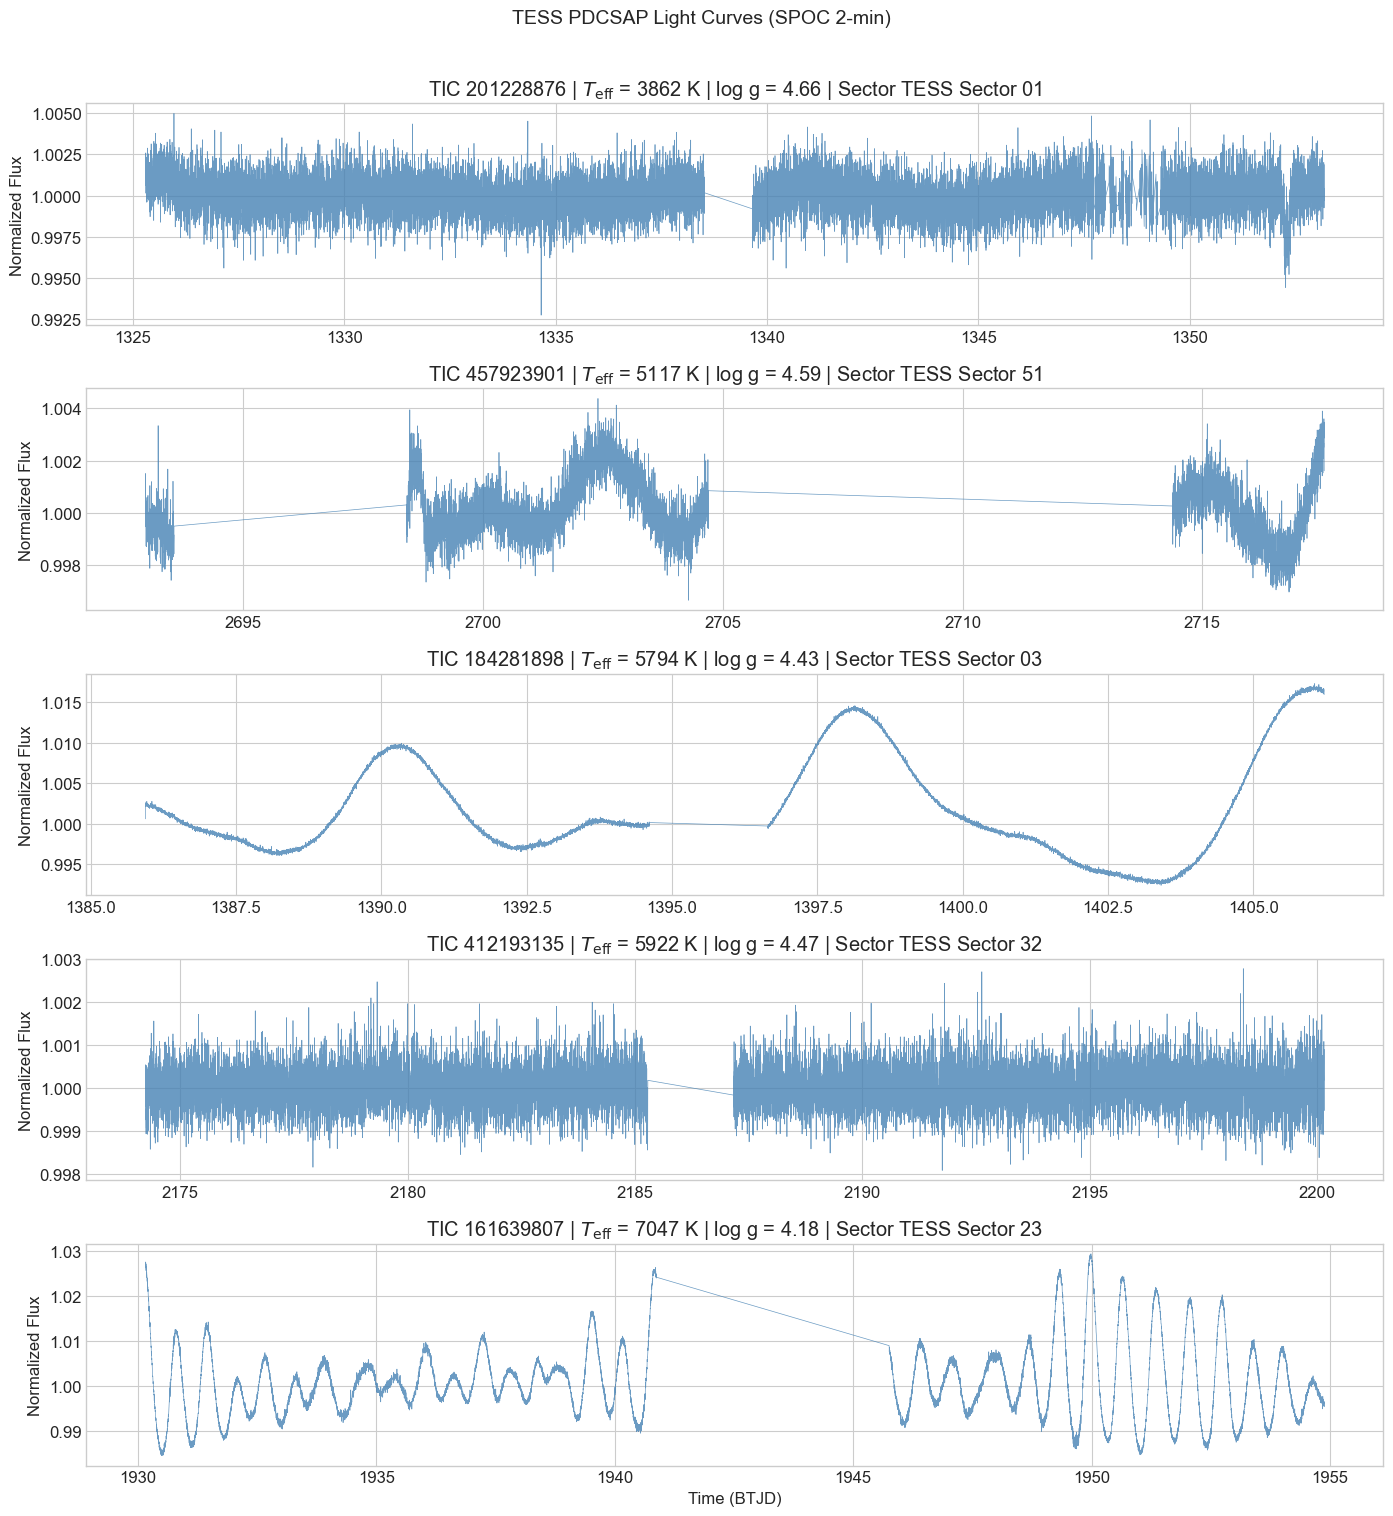

In [14]:
if len(selected) == 0:
    print("Skipping light curve plot — no stars available.")
else:
    n = len(selected)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, selected.iterrows()):
        tic_id = int(row['TIC'])
        try:
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
            lc = sr[0].download()
            lc = lc.select_flux('pdcsap_flux').remove_nans().normalize()
            ax.plot(lc.time.value, lc.flux.value, lw=0.5, color='steelblue', alpha=0.8)
            ax.set_ylabel('Normalized Flux')
            ax.set_title(
                f"TIC {tic_id} | $T_{{\\mathrm{{eff}}}}$ = {row['Teff']:.0f} K | "
                f"log g = {row['logg']:.2f} | Sector {sr[0].mission[0]}"
            )
        except Exception as e:
            ax.text(0.5, 0.5, f"TIC {tic_id}: download failed ({e})",
                    ha='center', va='center', transform=ax.transAxes)

    axes[-1].set_xlabel('Time (BTJD)')
    fig.suptitle('TESS PDCSAP Light Curves (SPOC 2-min)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

### What this section does
Download and plot PDCSAP light curves for 5 stars spanning the Teff range of the sample, to visually assess data quality and illustrate the diversity of stellar variability.

### Output interpretation
**Quality gaps**: Warnings about 30–39% of cadences being masked are normal — lightkurve's default bitmask removes momentum dumps, scattered light, and cosmic rays. The visible gaps in the plots are these masked intervals.

**Variability types across Teff**:

| Star | Teff | What we see | Why |
|---|---|---|---|
| TIC 201228876 | 3862 K (M dwarf) | Low-amplitude stochastic noise | Complex magnetic activity; rotation period likely exceeds the 27-day sector window |
| TIC 457923901 | 5117 K (K-type) | Intermittent modulation | Heavily affected by quality-flag gaps |
| TIC 184281898 | 5794 K (G-type) | Clean ~7-day sinusoidal modulation | Textbook starspot rotation — spots periodically transit the visible stellar disk |
| TIC 412193135 | 5922 K (G-type) | Nearly flat | A "quiet" Sun-like star with minimal spot coverage or unfavorable inclination |
| TIC 161639807 | 7047 K (F-type) | High-frequency coherent oscillations (~2-day period) | Likely **δ Scuti pressure-mode pulsations** ⚠️ — driven by internal waves, not surface activity. Stars above ~7000 K may need to be excluded |

### Discussion

> **Are these light curves clean enough, or do we need additional detrending? Any stars we should exclude by type (binaries, classical pulsators)?**
>
> - PDCSAP removes common systematic trends (scattered light, spacecraft systematics)
> - Obvious red flags to look for: sector-boundary jumps, high-amplitude periodic signals (binaries, pulsators)
> - Further detrending options: `wotan` flatten, sigma-clipping, or sector-level normalization

---
## Section 5: Degeneracy Demonstration

Find two main-sequence stars with similar log g (~4.4) but different Teff (~5000 K vs ~6000 K).
Their light curves look similar, but their BP-RP colors are clearly different — motivating color as a second input modality.

In [15]:
cool_cands = df[(df['logg'].between(4.25, 4.55)) & (df['Teff'].between(4800, 5200))].copy()
hot_cands  = df[(df['logg'].between(4.25, 4.55)) & (df['Teff'].between(5800, 6200))].copy()

print(f"Cool candidates (Teff ~5000 K, log g ~4.4): {len(cool_cands)}")
print(f"Hot  candidates (Teff ~6000 K, log g ~4.4): {len(hot_cands)}")

def find_star_with_tess(candidates, label):
    """Return the first candidate that has SPOC 2-min TESS data."""
    for _, row in candidates.iterrows():
        tic_id = int(row['ID'])
        try:
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
            if len(sr) > 0:
                print(f"  {label}: TIC {tic_id}, Teff={row['Teff']:.0f} K, logg={row['logg']:.2f}")
                return row, sr
        except Exception:
            continue
    return None, None

cool_row, cool_sr = find_star_with_tess(cool_cands, "cool (~5000 K)")
hot_row,  hot_sr  = find_star_with_tess(hot_cands,  "hot  (~6000 K)")

Cool candidates (Teff ~5000 K, log g ~4.4): 2217
Hot  candidates (Teff ~6000 K, log g ~4.4): 4390
  cool (~5000 K): TIC 238304232, Teff=5085 K, logg=4.41
  hot  (~6000 K): TIC 432549056, Teff=5819 K, logg=4.55


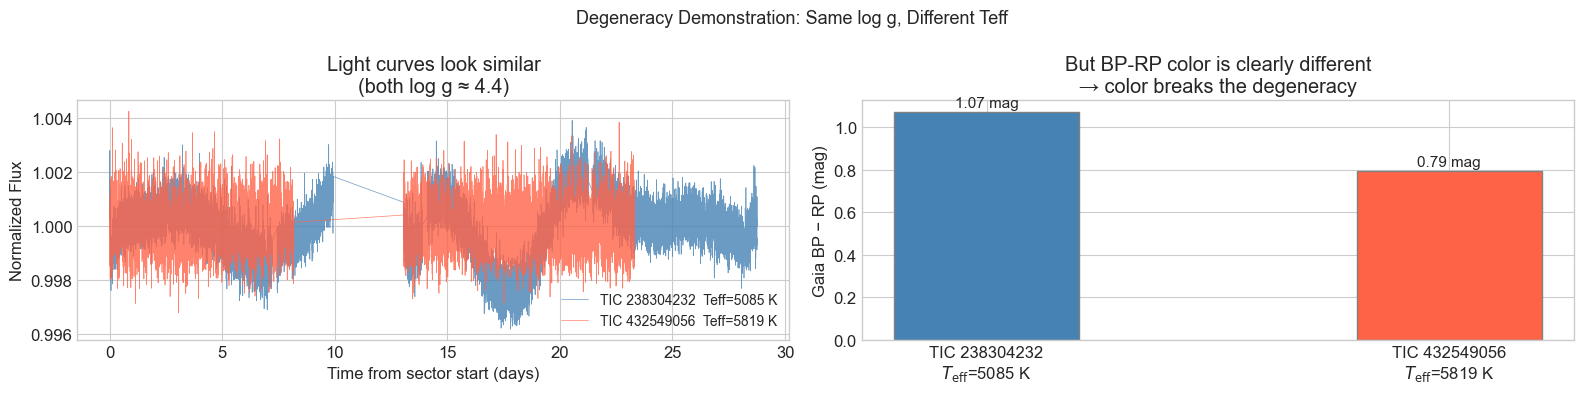

In [16]:
if cool_row is None or hot_row is None:
    print("Could not find a degenerate pair with TESS data in this sample.")
    print("Consider expanding the log g or Teff search window, or querying a larger initial sample.")
else:
    cool_lc = cool_sr[0].download().select_flux('pdcsap_flux').remove_nans().normalize()
    hot_lc  = hot_sr[0].download().select_flux('pdcsap_flux').remove_nans().normalize()

    cool_color = cool_row['gaiaBp'] - cool_row['gaiaRp'] if pd.notna(cool_row['gaiaBp']) else float('nan')
    hot_color  = hot_row['gaiaBp']  - hot_row['gaiaRp']  if pd.notna(hot_row['gaiaBp'])  else float('nan')

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Left: the two light curves — they look similar
    t_cool = cool_lc.time.value
    t_hot  = hot_lc.time.value
    # Align to start at t=0 for easier visual comparison
    axes[0].plot(t_cool - t_cool[0], cool_lc.flux.value, lw=0.5, alpha=0.8,
                 color='steelblue',
                 label=f"TIC {int(cool_row['ID'])}  Teff={cool_row['Teff']:.0f} K")
    axes[0].plot(t_hot - t_hot[0],   hot_lc.flux.value,  lw=0.5, alpha=0.8,
                 color='tomato',
                 label=f"TIC {int(hot_row['ID'])}  Teff={hot_row['Teff']:.0f} K")
    axes[0].set_xlabel('Time from sector start (days)')
    axes[0].set_ylabel('Normalized Flux')
    axes[0].set_title('Light curves look similar\n(both log g ≈ 4.4)')
    axes[0].legend(fontsize=10)

    # Right: BP-RP color — clearly different
    labels = [
        f"TIC {int(cool_row['ID'])}\n$T_{{\\mathrm{{eff}}}}$={cool_row['Teff']:.0f} K",
        f"TIC {int(hot_row['ID'])}\n$T_{{\\mathrm{{eff}}}}$={hot_row['Teff']:.0f} K"
    ]
    colors_vals = [cool_color, hot_color]
    bar_colors  = ['steelblue', 'tomato']
    bars = axes[1].bar(labels, colors_vals, color=bar_colors, edgecolor='grey', width=0.4)
    axes[1].set_ylabel('Gaia BP − RP (mag)')
    axes[1].set_title('But BP-RP color is clearly different\n→ color breaks the degeneracy')
    for bar, val in zip(bars, colors_vals):
        if not np.isnan(val):
            axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                         f"{val:.2f} mag", ha='center', va='bottom', fontsize=11)

    fig.suptitle('Degeneracy Demonstration: Same log g, Different Teff', fontsize=13)
    plt.tight_layout()
    plt.show()

**Question**: need something besides TESS to break the degeneracy — adding photometric colors like BP-RP as an additional input? 

**My idea**: concatenate a few scalar features (eg: colors like BP-RP, parallax, etc.) — onto the latent vector after the encoder. That way the light curve handles the temporal structure and the colors handle the temperature information. 



### What this section does
Find two main-sequence stars with the same log g (~4.4) but different Teff (~5000 K vs ~6000 K), show their light curves side by side, then compare their Gaia BP-RP colors — arguing that color information breaks the parameter degeneracy.

### Output interpretation
**Caveat on this pair**: The two light curves are visually distinguishable — the cooler star (5085 K) shows slightly larger variability amplitude. 

The light curve itself might carries some Teff information for this particular pair? Anyway the degeneracy is not perfectly demonstrated here.

### Discussion

> **This motivates adding Gaia BP-RP as a second input modality. Thoughts on how to incorporate it?**
>
> - Option A: concatenate a scalar BP-RP feature to the transformer's class token at inference time
> - Option B: encode BP-RP as a learned embedding and add it to every position
> - Option C: use the full Gaia XP spectrum as a second sequence input
> - Key question: should the model learn the color–Teff mapping from data, or is it injected as a prior?

## Quality Cuts

Filtering the TIC sample to stars suitable for Conv1D-VAE training.  
Cuts are applied in sequence; survival count is printed after each step.

In [3]:
import pandas as pd
import numpy as np

# Apply quality cuts in sequence starting from the full TIC query result (df_raw)
current = df_raw.copy()
print(f"Initial TIC sample: {len(current)} stars")

# Cut 1: Tmag < 7  (signal-to-noise — fainter stars show visibly noisy TESS light curves)
prev = len(current)
current = current[current['Tmag'] < 7]
_n_after_tmag = len(current)
print(f"After Tmag < 7: {_n_after_tmag} stars remaining (dropped {prev - _n_after_tmag})")

# Cut 2: parallax > 10 mas  (distance < 100 pc — lower extinction, better Gaia parameter quality)
prev = len(current)
current = current[current['plx'] > 10]
_n_after_plx = len(current)
print(f"After parallax > 10 mas: {_n_after_plx} stars remaining (dropped {prev - _n_after_plx})")

# Cut 3: drop rows where Teff or logg is null  (no physical labels → can't use for linear probing)
prev = len(current)
current = current.dropna(subset=['Teff', 'logg'])
_n_after_nulls = len(current)
print(f"After dropping null Teff/logg: {_n_after_nulls} stars remaining (dropped {prev - _n_after_nulls})")

# Cut 4: exclude SPLIT sources  (unresolved 2MASS doubles — unreliable photometry/parameters)
if 'disposition' in current.columns:
    prev = len(current)
    current = current[current['disposition'] != 'SPLIT']
    _n_after_split = len(current)
    print(f"After excluding SPLIT: {_n_after_split} stars remaining (dropped {prev - _n_after_split})")
else:
    _n_after_split = None
    print("Warning: 'disposition' column not found in TIC query result — skipping SPLIT exclusion step.")

df_clean = current.reset_index(drop=True)
print(f"\ndf_clean: {len(df_clean)} stars ready for TESS availability check.")

Initial TIC sample: 41233 stars
After Tmag < 7: 7121 stars remaining (dropped 34112)
After parallax > 10 mas: 7121 stars remaining (dropped 0)
After dropping null Teff/logg: 4917 stars remaining (dropped 2204)

df_clean: 4917 stars ready for TESS availability check.


### TESS 2-min Cadence Availability Check

For each star in `df_clean`, check whether TESS 2-min cadence (SPOC) data exists,
and how many sectors are available.

In [7]:
import lightkurve as lk
import pandas as pd
import numpy as np
import os
import time
import threading

CHECKPOINT_PATH = "sector_check_results.csv"
PROGRESS_EVERY  = 100
CHECKPOINT_EVERY = 100
QUERY_TIMEOUT   = 45    # seconds — kills hung MAST queries instead of blocking forever
QUERY_DELAY     = 0.5   # seconds between queries to avoid rate-limiting

print(f"df_clean has {len(df_clean)} rows")

# ── Resume from checkpoint ──────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    existing = pd.read_csv(CHECKPOINT_PATH)
    records  = existing.to_dict('records')
    done_ids = set(existing['TIC_ID'].astype(int))
    print(f"Resuming: {len(records)} stars already in {CHECKPOINT_PATH}, skipping them.")
else:
    records  = []
    done_ids = set()

todo = df_clean[~df_clean['ID'].astype(int).isin(done_ids)].copy()
print(f"Stars remaining: {len(todo)}  (already done: {len(done_ids)})  total: {len(df_clean)}")

if len(todo) == 0:
    print("All stars already checked. Loading from checkpoint.")
    df_sectors = pd.read_csv(CHECKPOINT_PATH)
else:
    # ── Per-query timeout (daemon thread, Windows-compatible) ───────────────
    def search_with_timeout(tic_id):
        """Run lk.search_lightcurve in a daemon thread; return (0, []) on hang or error."""
        result = [0, []]
        exc    = [None]
        def _run():
            try:
                sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
                n  = len(sr)
                try:
                    sectors = list(sr.table['sequence_number']) if n > 0 else []
                except Exception:
                    sectors = []
                result[0], result[1] = n, sectors
            except Exception as e:
                exc[0] = e
        t = threading.Thread(target=_run, daemon=True)
        t.start()
        t.join(QUERY_TIMEOUT)
        if t.is_alive():   # timed out — thread keeps running as daemon, harmless
            return 0, []
        if exc[0] is not None:
            raise exc[0]
        return result[0], result[1]

    # ── Main loop ───────────────────────────────────────────────────────────
    t0      = time.time()
    n_start = len(records)

    for i, (_, row) in enumerate(todo.iterrows(), start=1):
        tic_id = int(row['ID'])
        n, sectors = 0, []

        for attempt in range(3):
            try:
                n, sectors = search_with_timeout(tic_id)
                break
            except Exception:
                if attempt < 2:
                    time.sleep(2 ** attempt)   # 1 s, 2 s back-off on error

        records.append({'TIC_ID': tic_id, 'n_sectors': n, 'sector_list': sectors})
        time.sleep(QUERY_DELAY)

        total = n_start + i
        if i % PROGRESS_EVERY == 0:
            elapsed = time.time() - t0
            rate    = i / elapsed if elapsed > 0 else 0
            eta     = (len(todo) - i) / rate if rate > 0 else float('inf')
            print(f"  [{total:>5}/{len(df_clean)}]  this_run={i}  "
                  f"rate={rate:.2f} stars/s  ETA={eta/60:.1f} min")

        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(records).to_csv(CHECKPOINT_PATH, index=False)
            print(f"  -> checkpoint saved ({len(records)} rows)")

    df_sectors = pd.DataFrame(records)
    df_sectors.to_csv(CHECKPOINT_PATH, index=False)
    print(f"\nDone. {len(df_sectors)} total rows saved to {CHECKPOINT_PATH}.")

# ── Merge back into df_clean ────────────────────────────────────────────────
# Drop stale columns from any previous run to avoid _x/_y suffixes
stale = [c for c in ['TIC_ID', 'n_sectors', 'n_sectors_x', 'n_sectors_y'] if c in df_clean.columns]
if stale:
    df_clean = df_clean.drop(columns=stale)
df_clean = df_clean.merge(df_sectors[['TIC_ID', 'n_sectors']], left_on='ID', right_on='TIC_ID', how='left')
print(f"Sector data available for {df_clean['n_sectors'].notna().sum()} / {len(df_clean)} stars.")

df_clean has 4917 rows
Resuming: 257 stars already in sector_check_results.csv, skipping them.
Stars remaining: 4660  (already done: 257)  total: 4917


No data found for target "TIC 372191728".
No data found for target "TIC 81911786".


  [  357/4917]  this_run=100  rate=0.17 stars/s  ETA=440.1 min
  -> checkpoint saved (357 rows)


KeyboardInterrupt: 

In [8]:
import pandas as pd

# Cut 5: n_sectors >= 2  (need >= 2 sectors for adequate time coverage)
prev = len(df_clean)
df_final = df_clean[df_clean['n_sectors'] >= 2].copy().reset_index(drop=True)
print(f"After n_sectors >= 2: {len(df_final)} stars remaining (dropped {prev - len(df_final)})")
print()

display_cols = [c for c in ['ID', 'Tmag', 'Teff', 'logg', 'MH', 'plx', 'n_sectors']
                if c in df_final.columns]
print("First 10 rows of df_final:")
print(df_final[display_cols].head(10).to_string(index=False))

After n_sectors >= 2: 235 stars remaining (dropped 4682)

First 10 rows of df_final:
       ID   Tmag    Teff    logg        MH     plx  n_sectors
373061126 6.3452 7133.52 4.03529       NaN 14.2137          5
238301314 6.9059 5908.52 3.93936       NaN 15.2903          2
405267424 5.3985 7038.27 4.21509       NaN 26.7852          2
378534800 6.7085 5660.00 3.82940       NaN 16.4402          6
117927293 5.9418 6384.00 3.81453       NaN 16.5095          2
372131402 5.4758 5668.81 3.85585 -0.431016 28.2831          3
238432056 5.3971 5489.00 4.52192  0.070000 72.5764          3
417860263 6.5443 6362.34 4.44315       NaN 26.0548          6
258868211 6.9076 5939.90 4.42925 -0.222154 26.7173          2
395353076 6.4809 5846.00 3.94594       NaN 19.2461          2


TIC 189576919 (Tmag=3.6): 99 total windows, 79 pass NaN<10% cut (80% survival)
TIC 440042075 (Tmag=6.2): 99 total windows, 89 pass NaN<10% cut (90% survival)
TIC 381270241 (Tmag=7.0): 95 total windows, 83 pass NaN<10% cut (87% survival)


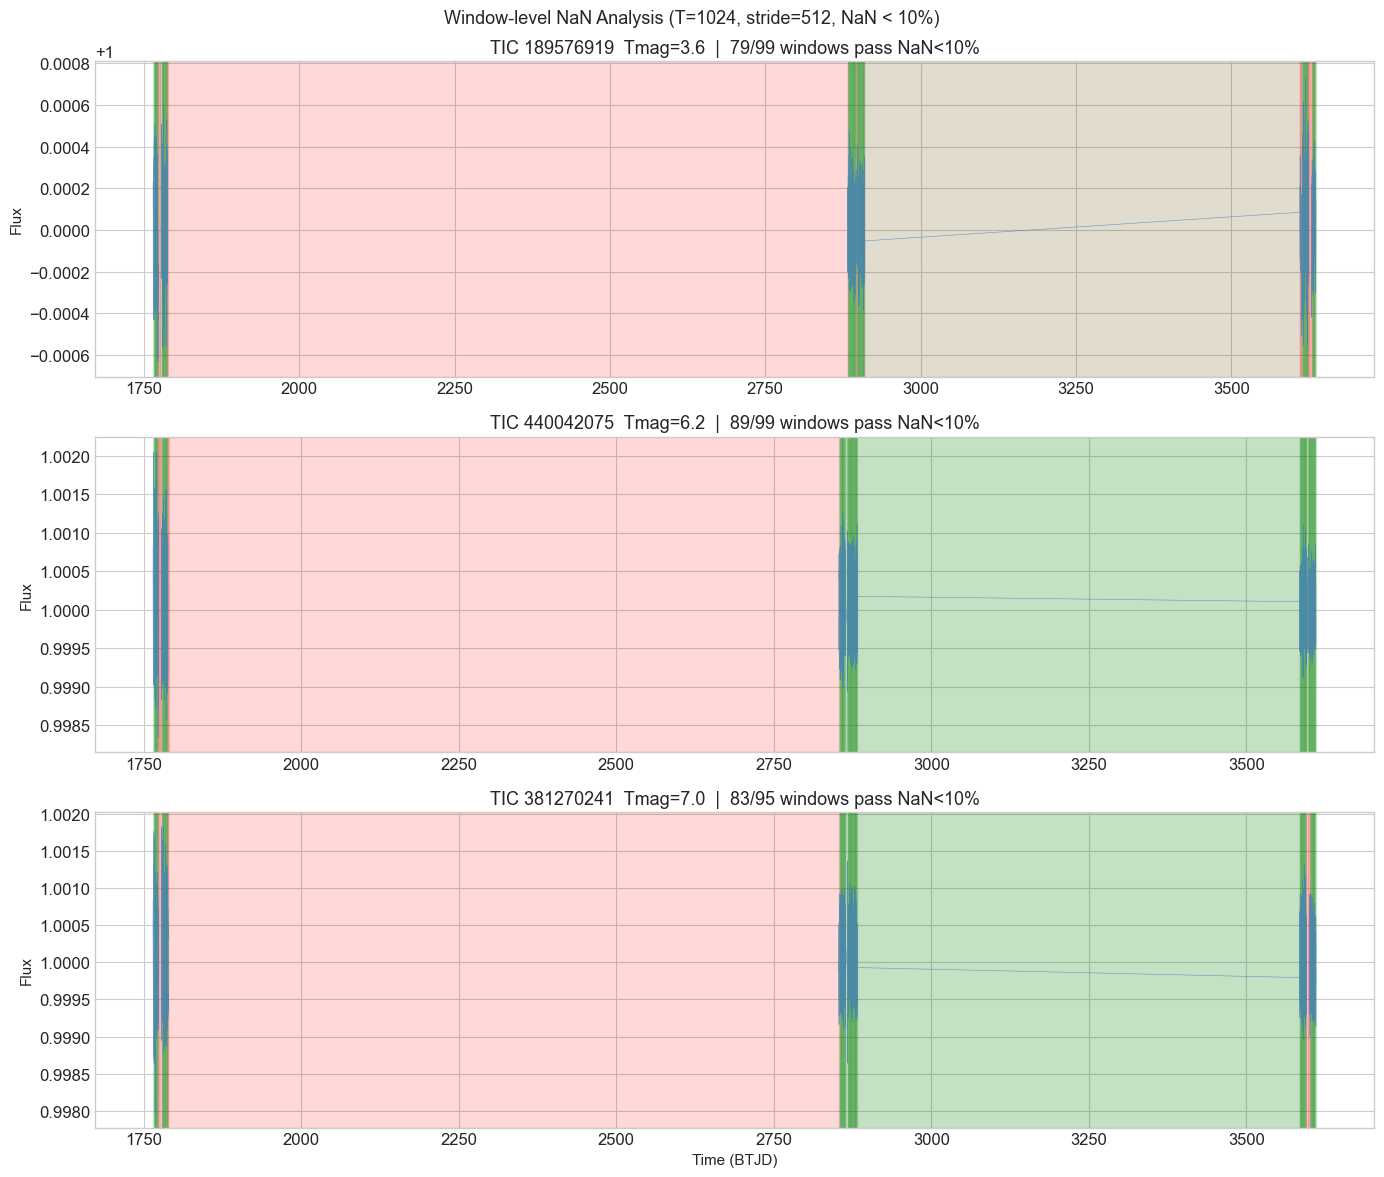

In [9]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

T = 1024
STRIDE = 512
NAN_THRESHOLD = 0.10

_window_summary = []

if len(df_final) == 0:
    print("df_final is empty — skipping window-level analysis.")
else:
    df_rep = df_final.sort_values('Tmag').reset_index(drop=True)
    n = len(df_rep)
    idxs = [0, n // 2, n - 1] if n >= 3 else list(range(n))
    rep_stars = df_rep.iloc[idxs].reset_index(drop=True)

    fig, axes = plt.subplots(len(rep_stars), 1, figsize=(14, 4 * len(rep_stars)), squeeze=False)

    for i, (_, row) in enumerate(rep_stars.iterrows()):
        tic_id = int(row['ID'])
        tmag = row['Tmag']
        ax = axes[i][0]
        try:
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
            lc_col = sr.download_all().stitch()
            flux = lc_col.flux.value.copy().astype(float)
            time_arr = lc_col.time.value

            # Apply QUALITY flag mask — set cadences with QUALITY != 0 to NaN
            try:
                quality = lc_col.quality.value
                flux[quality != 0] = np.nan
            except AttributeError:
                pass

            # Slide window T=1024, stride=512
            n_pts = len(flux)
            window_starts = list(range(0, n_pts - T + 1, STRIDE))
            n_total = len(window_starts)
            n_pass = 0
            pass_flags = []
            for s in window_starts:
                nan_frac = np.sum(np.isnan(flux[s:s + T])) / T
                ok = nan_frac < NAN_THRESHOLD
                pass_flags.append(ok)
                if ok:
                    n_pass += 1

            pct = 100 * n_pass / n_total if n_total > 0 else 0.0
            print(f"TIC {tic_id} (Tmag={tmag:.1f}): {n_total} total windows, "
                  f"{n_pass} pass NaN<10% cut ({pct:.0f}% survival)")
            _window_summary.append({'tic_id': tic_id, 'n_total': n_total, 'n_pass': n_pass})

            # Plot light curve with green (pass) / red (fail) window shading
            ax.plot(time_arr, flux, lw=0.4, color='steelblue', alpha=0.8)
            for s, ok in zip(window_starts, pass_flags):
                t_start = time_arr[s]
                t_end = time_arr[min(s + T - 1, n_pts - 1)]
                ax.axvspan(t_start, t_end, color='green' if ok else 'red',
                           alpha=0.12 if ok else 0.08)
            ax.set_title(f"TIC {tic_id}  Tmag={tmag:.1f}  |  {n_pass}/{n_total} windows pass NaN<10%",
                         fontsize=13)
            ax.set_ylabel("Flux", fontsize=11)
        except Exception as e:
            ax.text(0.5, 0.5, f"TIC {tic_id}: download failed\n{e}",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            _window_summary.append({'tic_id': tic_id, 'n_total': 0, 'n_pass': 0})
            print(f"TIC {tic_id} (Tmag={tmag:.1f}): download failed — {e}")

    axes[-1][0].set_xlabel("Time (BTJD)", fontsize=11)
    fig.suptitle("Window-level NaN Analysis (T=1024, stride=512, NaN < 10%)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# ---- Final Quality Cut Summary ----
print("========== Quality Cut Summary ==========")
print(f"Initial TIC sample:              {len(df_raw):>6} stars")
print(f"After Tmag < 7:                  {_n_after_tmag:>6} stars")
print(f"After parallax > 10 mas:         {_n_after_plx:>6} stars")
print(f"After dropping null Teff/logg:   {_n_after_nulls:>6} stars")
if _n_after_split is not None:
    print(f"After excluding SPLIT:           {_n_after_split:>6} stars")
else:
    print( "After excluding SPLIT:           skipped - column not found")
print(f"After n_sectors >= 2:            {len(df_final):>6} stars  <- df_final")
print()
print("Window-level preview (3 stars):")
for entry in _window_summary:
    print(f"  TIC {entry['tic_id']}: {entry['n_pass']}/{entry['n_total']} windows pass NaN<10%")
print()
if len(df_final) >= 50:
    print("Recommended next step:")
    print("  df_final has >= 50 stars with adequate windows -> proceed with light curve pipeline")
else:
    print("Recommended next step:")
    print("  df_final has < 50 stars -> consider relaxing Tmag cut to < 9 or adding power spectrum as auxiliary input")
print("=========================================")

========== Quality Cut Summary ==========
Initial TIC sample:               41233 stars
After Tmag < 7:                    7121 stars
After parallax > 10 mas:           7121 stars
After dropping null Teff/logg:     4917 stars
After excluding SPLIT:           skipped - column not found
After n_sectors >= 2:                43 stars  <- df_final

Window-level preview (3 stars):
  TIC 116988032: 84/101 windows pass NaN<10%
  TIC 376986714: 304/360 windows pass NaN<10%
  TIC 11736895: 76/93 windows pass NaN<10%

Recommended next step:
  df_final has < 50 stars -> consider relaxing Tmag cut to < 9 or adding power spectrum as auxiliary input
